# Cleaning Datasets
## Importing Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow
import seaborn as sns

## Reading in Datasets
### Turbine Monthly Datasets

In [19]:
# load in raw turbine data
jan_wide = pd.read_parquet('../../data/raw/Alta10_Turbine_Points_10m_2026-01.parquet')
feb_wide = pd.read_parquet('../../data/raw/Alta10_Turbine_Points_10m_2026-02.parquet')
mar_wide = pd.read_parquet('../../data/raw/Alta10_Turbine_Points_10m_2026-03.parquet')
apr_wide = pd.read_parquet('../../data/raw/Alta10_Turbine_Points_10m_2026-04.parquet')
may_wide = pd.read_parquet('../../data/raw/Alta10_Turbine_Points_10m_2026-05.parquet')
jun_wide = pd.read_parquet('../../data/raw/Alta10_Turbine_Points_10m_2026-06.parquet')
jul_wide = pd.read_parquet('../../data/raw/Alta10_Turbine_Points_10m_2026-07.parquet')
aug_wide = pd.read_parquet('../../data/raw/Alta10_Turbine_Points_10m_2026-08.parquet')
sep_wide = pd.read_parquet('../../data/raw/Alta10_Turbine_Points_10m_2026-09.parquet')

### Met Mast Monthly Datasets

In [20]:
# load in raw met mast data
jan_mm_raw = pd.read_parquet('../../data/raw/Alta10_MetMast_WindSpeed_10m_2026-01.parquet')
feb_mm_raw = pd.read_parquet('../../data/raw/Alta10_MetMast_WindSpeed_10m_2026-02.parquet')
mar_mm_raw = pd.read_parquet('../../data/raw/Alta10_MetMast_WindSpeed_10m_2026-03.parquet')
apr_mm_raw = pd.read_parquet('../../data/raw/Alta10_MetMast_WindSpeed_10m_2026-04.parquet')
may_mm_raw = pd.read_parquet('../../data/raw/Alta10_MetMast_WindSpeed_10m_2026-05.parquet')
jun_mm_raw = pd.read_parquet('../../data/raw/Alta10_MetMast_WindSpeed_10m_2026-06.parquet')
jul_mm_raw = pd.read_parquet('../../data/raw/Alta10_MetMast_WindSpeed_10m_2026-07.parquet')
aug_mm_raw = pd.read_parquet('../../data/raw/Alta10_MetMast_WindSpeed_10m_2026-08.parquet')
sep_mm_raw = pd.read_parquet('../../data/raw/Alta10_MetMast_WindSpeed_10m_2026-09.parquet')

## Analyzing Missing Date Values
### Turbine Data Sets

In [21]:
# defining a list of the monthly datasets
month = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September']
monthly_wide = [jan_wide, feb_wide, mar_wide, apr_wide, may_wide, jun_wide, jul_wide, aug_wide, sep_wide]
exp_counts_wide = [4464, 4032, 4464, 4320, 4464, 4320, 4464, 4464, 4320]

# finding the number of observations below expected in each dataset
for n in range(9):
    print(month[n], ':', exp_counts_wide[n] - monthly_wide[n].shape[0])

January : 0
February : 0
March : 6
April : 0
May : 0
June : 0
July : 0
August : 0
September : 288


In [22]:
# defining a function to mark missing date/times in the datasets
def missing_times(df, year, month):
    # defines the starting time of 10 minute incriments
    start = pd.Timestamp(year = year, month = month, day = 1)
    end = start + pd.offsets.MonthBegin(1) - pd.Timedelta(minutes=10)
    expected = pd.date_range(start, end, freq = '10min')

    # calculates missing values
    missing = expected.difference(df.index)

    # returns missing datetimes
    return missing

In [23]:
# finding the missing times in March
missing_times(mar_wide, 2026, 3)

DatetimeIndex(['2026-03-08 02:00:00', '2026-03-08 02:10:00',
               '2026-03-08 02:20:00', '2026-03-08 02:30:00',
               '2026-03-08 02:40:00', '2026-03-08 02:50:00'],
              dtype='datetime64[us]', freq='10min')

The March dataset is missing an hour on March 8, 2026 from 2:00 AM to 2:50 AM. 

In [24]:
# finding the missing times in September
missing_times(sep_wide, 2026, 9)

DatetimeIndex(['2026-09-29 00:00:00', '2026-09-29 00:10:00',
               '2026-09-29 00:20:00', '2026-09-29 00:30:00',
               '2026-09-29 00:40:00', '2026-09-29 00:50:00',
               '2026-09-29 01:00:00', '2026-09-29 01:10:00',
               '2026-09-29 01:20:00', '2026-09-29 01:30:00',
               ...
               '2026-09-30 22:20:00', '2026-09-30 22:30:00',
               '2026-09-30 22:40:00', '2026-09-30 22:50:00',
               '2026-09-30 23:00:00', '2026-09-30 23:10:00',
               '2026-09-30 23:20:00', '2026-09-30 23:30:00',
               '2026-09-30 23:40:00', '2026-09-30 23:50:00'],
              dtype='datetime64[us]', length=288, freq='10min')

The September dataset is missing 2 entire days, September 29, 2026 and September 30, 2026. 
### Met Mast Datasets

In [25]:
# defining a list of the monthly datasets
monthly_met = [jan_mm_raw, feb_mm_raw, mar_mm_raw, apr_mm_raw, may_mm_raw, jun_mm_raw, jul_mm_raw, aug_mm_raw, sep_mm_raw]
exp_counts_met = [4464, 4032, 4464, 4320, 4464, 4320, 4464, 4464, 4320]

# finding the number of observations below expected in each dataset
for n in range(9):
    print(month[n], ':', exp_counts_met[n] - monthly_met[n].shape[0])

January : 0
February : 0
March : 6
April : 0
May : 0
June : 0
July : 0
August : 0
September : 0


In [26]:
# finding the missing times in March
missing_times(mar_mm_raw, 2026, 3)

DatetimeIndex(['2026-03-08 02:00:00', '2026-03-08 02:10:00',
               '2026-03-08 02:20:00', '2026-03-08 02:30:00',
               '2026-03-08 02:40:00', '2026-03-08 02:50:00'],
              dtype='datetime64[us]', freq='10min')

It appears the same times are missing from the met mast data as the turbine datasets. 
## Cleaning Datasets
### Converting Turbine Datasets to Long Format and Changing Variable Names

In [27]:
# reordering and renaming variables with a dictionary
mapping1 = {'utcTime': 'utc', 'turbine': 'turbine', 'AirDensity': 'air_density', 'KPI-TemperatureAmbient-Merged': 'KPI_temp_ambient_merged', 
           'KPI-TemperatureAmbient': 'KPI_temp_ambient', 'KPI-TheoreticalPower': 'KPI_theoretical_power', 'KPI-RealPowerAC': 'KPI_real_power_ac',
           'RealPowerAC': 'real_power_ac', 'KPI-WindSpeed': 'KPI_wind_speed', 'WindSpeed': 'wind_speed', 'WindDirection': 'wind_direction', 
           'WindDirectionRelative': 'wind_direction_relative', 'NacellePosition': 'nacelle_pos', 'BladePosition1': 'blade_1_pos', 
           'BladePosition2': 'blade_2_pos', 'BladePosition3': 'blade_3_pos', 'BladeSetpointPosition1': 'blade_1_setpos', 
           'BladeSetpointPosition2': 'blade_2_setpos', 'BladeSetpointPosition3': 'blade_3_setpos'}

# defining a function to convert the wide format datasets into long format datasets
def reshape_month_turbine(df):
    # defines utcTime as index for rows in new dataset
    df = df.set_index('utcTime')

    # splits the columns into the turbine name and variable name
    parts = df.columns.str.extract(r"^ALTA\d+-SCEWF-(WTG\d+)-(.+)$")
    parts.columns = ['turbine', 'variable']

    # outputs problematic columns from this split
    bad = df.columns[parts['turbine'].isna()]
    if len(bad):
        raise ValueError(f"Columns that didn't match the pattern: {list(bad)}")

    # creates a copy of the dataframe
    df = df.copy()
    df.columns = pd.MultiIndex.from_frame(parts)

    # creates the long version of the dataset
    long = df.stack(level = 'turbine', future_stack = True).reset_index()
    long['turbine'] = long['turbine'].astype(str)
    long.columns.name = None
    long.sort_values(['turbine', 'utcTime']).reset_index(drop = True)

    # returns new dataset with renamed and reordered columns
    return long[list(mapping1)].rename(columns = mapping1)

In [28]:
# applying the reshape_month_turbine() function to each monthly dataset
jan = reshape_month_turbine(jan_wide)
feb = reshape_month_turbine(feb_wide)
mar = reshape_month_turbine(mar_wide)
apr = reshape_month_turbine(apr_wide)
may = reshape_month_turbine(may_wide)
jun = reshape_month_turbine(jun_wide)
jul = reshape_month_turbine(jul_wide)
aug = reshape_month_turbine(aug_wide)
sep = reshape_month_turbine(sep_wide)

#### Quick Check for Missing Data in Long Dataset

In [29]:
# defining a list of the monthly datasets
month = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September']
monthly = [jan, feb, mar, apr, may, jun, jul, aug, sep]
exp_counts = [209808, 189504, 209808, 203040, 209808, 203040, 209808, 209808, 203040]

# finding the number of observations below expected in each dataset
for n in range(9):
    print(month[n], ':', exp_counts[n] - monthly[n].shape[0])

January : 0
February : 0
March : 282
April : 0
May : 0
June : 0
July : 0
August : 0
September : 13536


The months of March and September have missing time values. However, this completely aligns with the missing time findings in the wide-format datasets.

### Changing Variable Names in Met Mast Datasets

In [30]:
# reordering and renaming variables with a dictionary
mapping2 = {'utcTime': 'utc', 'ALTA10-MetStation-WindSpeed': 'mm_wind_speed_1', 'ALTA10-MetStation-WindSpeedHeight2': 'mm_wind_speed_2', 
            'ALTA10-MetStation-WindSpeedHeight3': 'mm_wind_speed_3', 'ALTA10-MetStation-WindSpeedHubHeight': 'mm_wind_speed_hh', 
            'ALTA10-MetStation-WindDirection': 'mm_wind_direction_1', 'ALTA10-MetStation-WindDirectionHeight2': 'mm_wind_direction_2',
            'ALTA10-MetStation-WindDirectionHeight3': 'mm_wind_direction_3', 'ALTA10-MetStation-WindDirectionHubHeight': 'mm_wind_direction_hh', 
            'ALTA10-MetStation-PressureBarometric': 'mm_pressure_bar_1', 'ALTA10-MetStation-PressureBarometric2': 'mm_pressure_bar_2', 
            'ALTA10-MetStation-RelativeHumidity': 'mm_rel_humidity_1', 'ALTA10-MetStation-RelativeHumidity2': 'mm_rel_humidity_2', 
            'ALTA10-MetStation-TemperatureAmbient': 'mm_temp_amb'}

# reordering and renaming variables with a second dictionary for September without 'ALTA10-MetStation-WindSpeed'
mapping3 = {'utcTime': 'utc', 'ALTA10-MetStation-WindSpeedHeight2': 'mm_wind_speed_2', 
            'ALTA10-MetStation-WindSpeedHeight3': 'mm_wind_speed_3', 'ALTA10-MetStation-WindSpeedHubHeight': 'mm_wind_speed_hh', 
            'ALTA10-MetStation-WindDirection': 'mm_wind_direction_1', 'ALTA10-MetStation-WindDirectionHeight2': 'mm_wind_direction_2',
            'ALTA10-MetStation-WindDirectionHeight3': 'mm_wind_direction_3', 'ALTA10-MetStation-WindDirectionHubHeight': 'mm_wind_direction_hh', 
            'ALTA10-MetStation-PressureBarometric': 'mm_pressure_bar_1', 'ALTA10-MetStation-PressureBarometric2': 'mm_pressure_bar_2', 
            'ALTA10-MetStation-RelativeHumidity': 'mm_rel_humidity_1', 'ALTA10-MetStation-RelativeHumidity2': 'mm_rel_humidity_2', 
            'ALTA10-MetStation-TemperatureAmbient': 'mm_temp_amb'}

# creates a function for renaming the columns
def rename_month_met(df):
    df = df
    
    df.sort_values(['utcTime']).reset_index(drop = True)
    
    # returns new dataset with renamed and reordered columns
    return df[list(mapping2)].rename(columns = mapping2)

# creates a second function for renaming the columns in September where the variable is missing
def rename_month_met2(df):
    df = df
    
    df.sort_values(['utcTime']).reset_index(drop = True)
    
    # returns new dataset with renamed and reordered columns
    return df[list(mapping3)].rename(columns = mapping3)

In [31]:
# applying the rename_month_met() function to each monthly dataset
jan_mm = rename_month_met(jan_mm_raw)
feb_mm = rename_month_met(feb_mm_raw)
mar_mm = rename_month_met(mar_mm_raw)
apr_mm = rename_month_met(apr_mm_raw)
may_mm = rename_month_met(may_mm_raw)
jun_mm = rename_month_met(jun_mm_raw)
jul_mm = rename_month_met(jul_mm_raw)
aug_mm = rename_month_met(aug_mm_raw)
sep_mm = rename_month_met2(sep_mm_raw)

## Creating a Single Dataset with All Months

In [32]:
# creating a list of met masts datasets
monthly_mm = [jan_mm, feb_mm, mar_mm, apr_mm, may_mm, jun_mm, jul_mm, aug_mm, sep_mm]

In [33]:
# creating a datasets stacking all monthly data
scada = pd.concat(monthly)
metmasts = pd.concat(monthly_mm)

In [35]:
# exporting full scada dataset to cleaned data folder
scada.to_parquet('../../data/processed/scada_data.parquet', index = False)

In [36]:
# exporting full met masts dataset to cleaned data folder
metmasts.to_parquet('../../data/processed/metmasts_data.parquet', index = False)

## Missing Data Analysis
### Turbine Data Sets

In [37]:
# analyzing which columns have the most missing data
na_pct = scada.isna().mean()

print(na_pct.sort_values(ascending = False))

blade_1_setpos             0.342165
blade_3_setpos             0.342151
blade_2_setpos             0.342150
real_power_ac              0.341689
blade_1_pos                0.304447
blade_3_pos                0.289025
blade_2_pos                0.288620
nacelle_pos                0.220685
KPI_wind_speed             0.085207
KPI_temp_ambient           0.081829
KPI_real_power_ac          0.077143
wind_speed                 0.076460
wind_direction_relative    0.076432
wind_direction             0.076420
air_density                0.005018
KPI_temp_ambient_merged    0.003934
KPI_theoretical_power      0.000371
turbine                    0.000000
utc                        0.000000
dtype: float64


The columns with the most missing values are the blade set position data as well as blade position data. The real power in ac data is also missing at a high rate. 
#### Missing Data Per Month and Per Variable

In [38]:
# creating a new month variable in the scada dataset to group by
scada['month'] = scada['utc'].dt.to_period('M')

# grouping by each month and summarizing the proportion of missing data within each month and variable
missing_by_month = (scada.drop(columns = ['utc', 'turbine']).set_index('month').isna().groupby(level = 'month').mean().round(3))

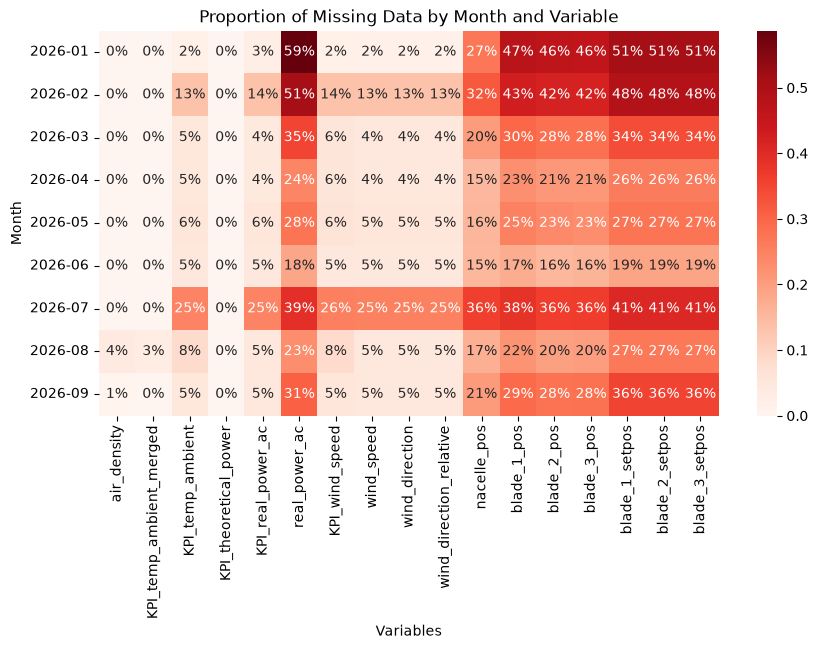

In [39]:
# creating a heatmap to show which variables within each month are the most missing
plt.figure(figsize = (10, 5))
sns.heatmap(missing_by_month, annot = True, fmt = '.0%', cmap = 'Reds')
plt.xlabel('Variables')
plt.ylabel('Month')
plt.title('Proportion of Missing Data by Month and Variable')
plt.show()

#### Missing Data Per Turbine and Variable

In [40]:
# grouping by each month and summarizing the proportion of missing data within each turbine and variable
missing_by_turbine = (scada.drop(columns = ['utc']).set_index('turbine').isna().groupby(level = 'turbine').mean().round(3))

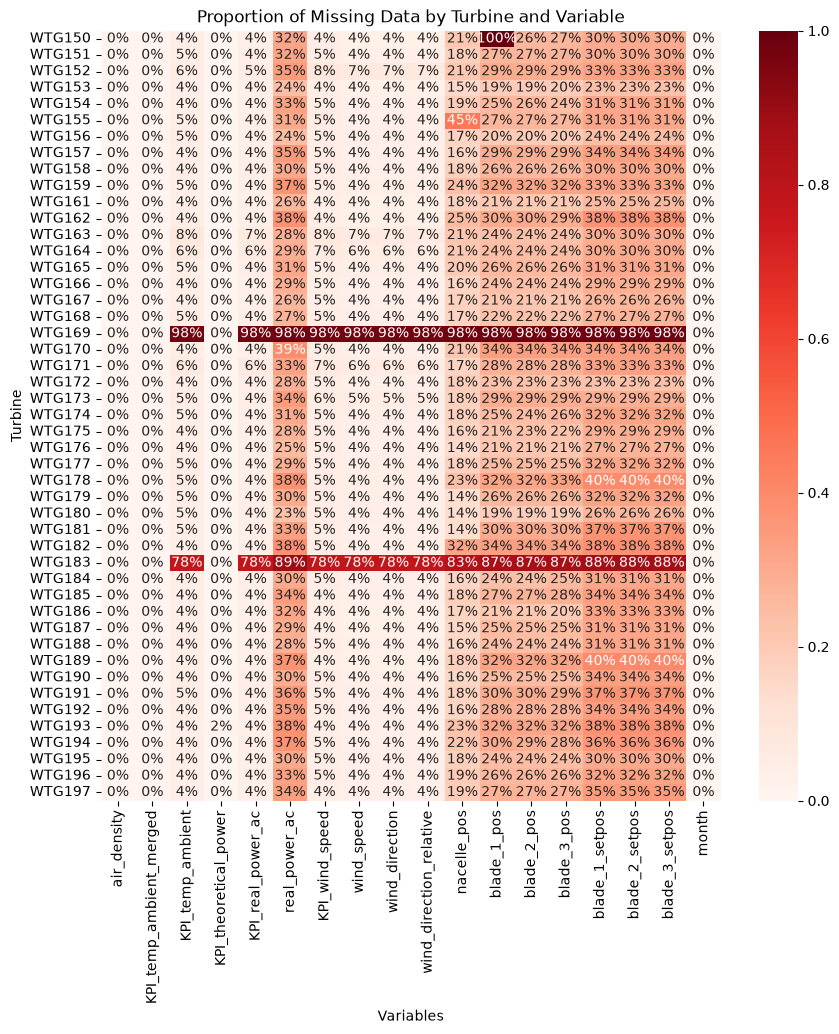

In [41]:
# creating a heatmap to show which variables within each turbine are the most missing
plt.figure(figsize = (10, 10))
sns.heatmap(missing_by_turbine, annot = True, fmt = '.0%', cmap = 'Reds')
plt.xlabel('Variables')
plt.ylabel('Turbine')
plt.title('Proportion of Missing Data by Turbine and Variable')
plt.show()

### Met Mast Datasets

In [42]:
# analyzing which columns have the most missing data
na_pct_mm = metmasts.isna().mean()

print(na_pct_mm.sort_values(ascending = False))

mm_wind_speed_1         0.999440
mm_pressure_bar_1       0.679413
mm_temp_amb             0.198163
mm_wind_speed_2         0.029817
mm_wind_speed_hh        0.023889
mm_wind_speed_3         0.023864
mm_wind_direction_hh    0.023864
mm_wind_direction_1     0.023864
mm_wind_direction_3     0.023864
mm_wind_direction_2     0.023864
mm_rel_humidity_2       0.023864
mm_pressure_bar_2       0.023864
mm_rel_humidity_1       0.023839
utc                     0.000000
dtype: float64


#### Missing Data Per Month and Per Variable

In [43]:
# creating a new month variable in the scada dataset to group by
metmasts['month'] = metmasts['utc'].dt.to_period('M')

# grouping by each month and summarizing the proportion of missing data within each month and variable
missing_by_month_mm = (metmasts.drop(columns = ['utc']).set_index('month').isna().groupby(level = 'month').mean().round(3))

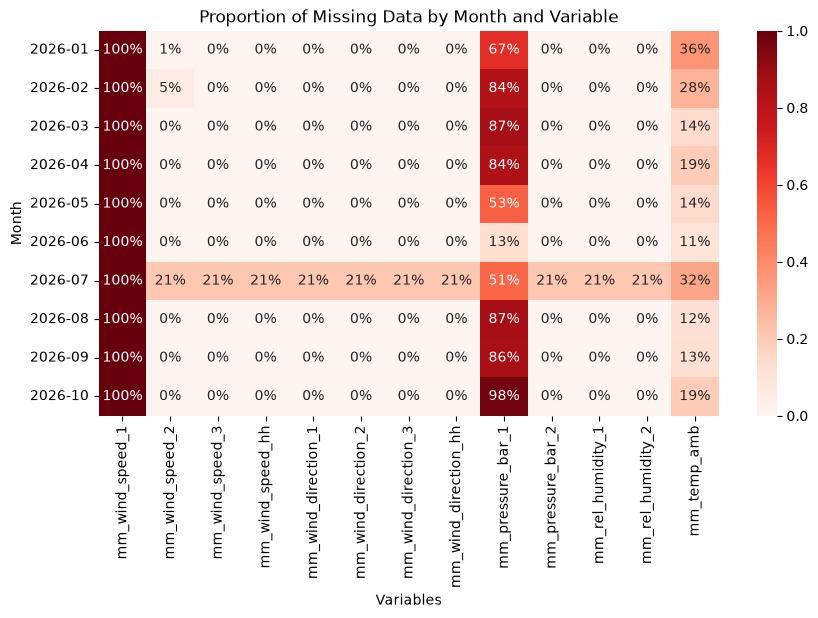

In [44]:
# creating a heatmap to show which variables within each month are the most missing
plt.figure(figsize = (10, 5))
sns.heatmap(missing_by_month_mm, annot = True, fmt = '.0%', cmap = 'Reds')
plt.xlabel('Variables')
plt.ylabel('Month')
plt.title('Proportion of Missing Data by Month and Variable')
plt.show()